## RAG Pipeline - Data Ingestion to Vector DB Pipeline 

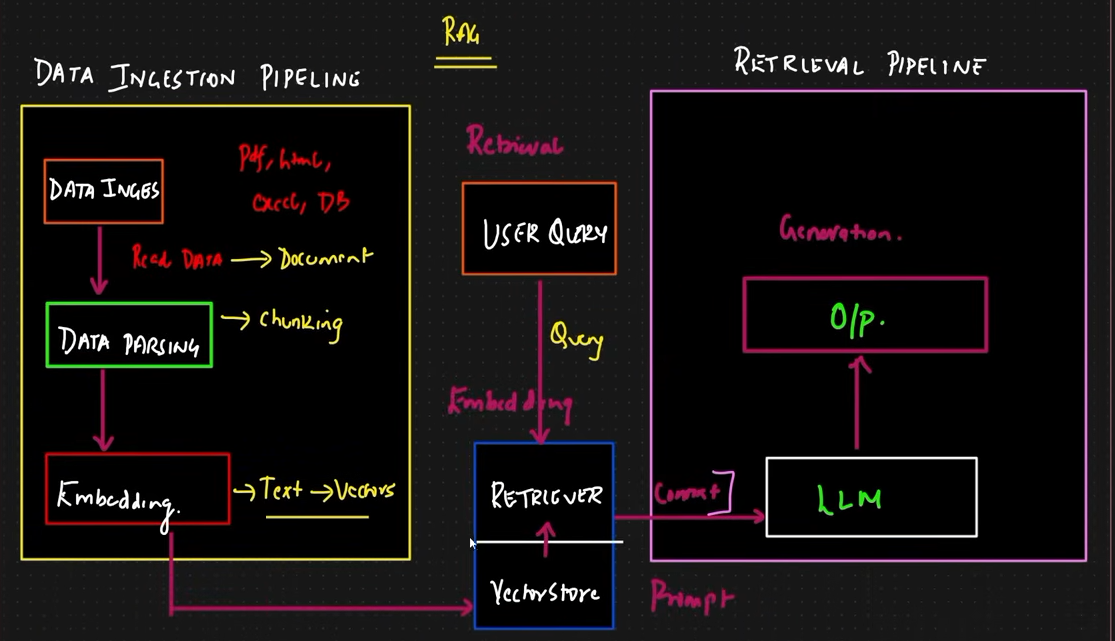

In [13]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\manas\AppData\Local\Temp\ipykernel_33528\3933654057.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader


In [14]:
### read all the pdfs inside the directory 
def process_all_pdfs(pdf_directory): 
    """Process all PDF files in a directory"""

    all_documents = []
    pdf_dir = Path(pdf_directory)

    # Find all PDF files recursively 
    pdf_files = list(pdf_dir.glob("**/*.pdf"))

    print(f"Found {len(pdf_files)} PDF files to precess")

    for pdf_file in pdf_files: 
        print(f"\nProcessing: {pdf_file.name}")
        try: 
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()

            # Add source information to meta data 
            for doc in documents: 
                doc.metadata['source_file'] = pdf_file.name 
                doc.metadata['file_type'] = 'pdf'

            all_documents.extend(documents)
            print(f" Loaded {len(documents)} pages")

        except Exception as e: 
            print(f" Error: {e}")

    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

#process all PDFs in the data diretory 
all_pdf_documents = process_all_pdfs("./data")



Found 2 PDF files to precess

Processing: attention.pdf
 Loaded 15 pages

Processing: WordEmbeddingsinNLP.pdf
 Loaded 18 pages

Total documents loaded: 33


In [15]:
all_pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toront

In [16]:
### Text splitting get into chunks 

def split_documents(documents, chunk_size = 1000, chunk_overlap = 200): 
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = chunk_size, 
        chunk_overlap = chunk_overlap, 
        length_function = len, 
        separators=["\n\n", "\n", " ", ""] # this makes sure that the chunks that you separate are not at random but is from paragraph, then sentences , then spaces and at last resort raw text
        
    )

    split_docs = text_splitter.split_documents(documents) # this is not a recursive function it is calling a different function (not the split_documents funciton that we created)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks") 

    # show example of a chunk 
    if split_docs: 
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")

    return split_docs 

In [17]:
chunks= split_documents(all_pdf_documents) 
chunks

Split 33 documents into 87 chunks

Example chunk:
Content: Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
...
Metadata: {'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toront

### Embeddings and Vector Database 


In [18]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity
import os 

In [19]:
class EmbeddingManager: 
    """Handles document embeddings generation using Sentence Transformer"""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"): 
        """
        Initialize the embedding manager 

        Args: 
            model_name : HuggingFace model name for sentence embeddings 
        """

        self.model_name =model_name 
        self.model = None 
        self._load_model()


    def _load_model(self): 
        """Load the Sentence Transformer model """
        try: 
            print(f"Loading embeddings model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_embedding_dimension()}")
        except Exception as e: 
            print(f"Error loading model {self.model_name}: {e}")
            raise ValueError("Model not loaded")



    def generate_embeddings(self, texts: List[str])-> np.ndarray: 
        """
        Generate embeddings for a list of texts 

        Args: 
            texts: List of text strings to embed 

        Returns: 
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """

        if not self.model: 
            raise ValueError("Model not loaded")

        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings



In [20]:
## initialize the embedding manager 
embedding_manager = EmbeddingManager()
embedding_manager

Loading embeddings model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11549.92it/s]


Model loaded successfully. Embedding dimension: 384


### Vector Store 

In [21]:
class VectorStore: 
    """Manages document embeddings in a ChromaDB vector store"""

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "./data/vector_store"): 
        """
        Initialize the vector store 

        Args: 
            collection_name: Name of the ChromaDB collection 
            persist_directory: Directory to presist the vector store 
        """

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None 
        self.collection = None
        self._initialize_store()

    def _initialize_store(self): 
        """Initialize ChromaDB client and collection"""

        try: 
            # Create persistent ChormaDB client 
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path = self.persist_directory)

            # Get or create collection 
            self.collection = self.client.get_or_create_collection(
                name = self.collection_name, 
                metadata ={"description": "PDF document embeddings for RAG "}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")

        except Exception as e: 
            print(f"Error initializing vector store: {e}")
            raise 

    def add_documents(self, documents: List[Any], embeddings: np.ndarray): 
        """
        Add documents and their embeddings to the vector store 

        Args: 
            documents; List of Langchain documents 
            embeddings: Corresponding embeddings for the documents 
        """

        if len(documents) != len(embeddings): 
            raise ValueError("Number of documents must match number of embeddings")

        print(f"Adding {len(documents)} documents to vector store...")

        # prepare data for chromaDB 
        ids = [] 
        metadatas = []
        documents_text =[]
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)): 
            # Generate unique ID 
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)


            # Prepare metadata 
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i 
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)

            # Document content 
            documents_text.append(doc.page_content)

            #Embedding 
            embeddings_list.append(embedding.tolist())

        # add to collection 
        try: 
            self.collection.add(
                ids = ids, 
                embeddings= embeddings_list, 
                metadatas = metadatas, 
                documents = documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")

        except Exception as e: 
            print(f"Error adding documents to vector store: {e}")
            raise 
        



In [22]:
vectorstore = VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 0


In [23]:
chunks

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toront

In [24]:
## Convert the text to embeddings 
# collect the texts
texts= [doc.page_content for doc in chunks]

## Generate the embedding 
embeddings= embedding_manager.generate_embeddings(texts)


## Store in the vector database 
vectorstore.add_documents(chunks, embeddings)


Generating embeddings for 87 texts...


Batches: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]

Generated embeddings with shape: (87, 384)
Adding 87 documents to vector store...
Successfully added 87 documents to vector store
Total documents in collection: 87


In [28]:
class RAGRetriever: 
    """Handles query based retrieval from the vector store"""

    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager): 
        """
        Initialize the retriever 

        Args: 
            vector_store: Vector store containing document embeddings 
            embedding_manager: Manager for generating query embeddings 
        """

        self.vector_store = vector_store
        self.embedding_manager = embedding_manager


    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]: 
        """
        Retrieve relevant documents for a query 

        Args: 
            query: The search query 
            top_k: Number of top results to return 
            score_threshold: Minimum similarity score threshold 

        Returns: 
            List of dictionaries containing retrieved documents and metadata 
        """

        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, score threshold: {score_threshold}")

        # Generate query embedding 
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]

        # Search in vector store 
        try: 
            results = self.vector_store.collection.query(
                query_embeddings = [query_embedding.tolist()], 
                n_results = top_k
            )

            # Process results 
            retrieved_docs = []

            if results['documents'] and results['documents'][0]: 
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]

                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)): 
                    # Convert distance to similarity score (ChromaDB uses cosine distance) 
                    similarity_score = 1 - distance 

                    if similarity_score >= score_threshold: 
                        retrieved_docs.append({
                            'id': doc_id, 
                            'content': document, 
                            'metadata': metadata, 
                            'similarity_score': similarity_score, 
                            'distance': distance, 
                            'rank': i+1
                        })

                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else: 
                print("No  Documents found")

            return retrieved_docs
        
        except Exception as e: 
            print(f"Error during retrieval: {e}")
            return []

In [29]:
rag_retriever = RAGRetriever(vectorstore, embedding_manager)
rag_retriever

In [30]:
rag_retriever.retrieve("What is attention is all you need")

Retrieving documents for query: 'What is attention is all you need'
Top K: 5, score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 155.61it/s]

Generated embeddings with shape: (1, 384)
Retrieved 1 documents (after filtering)


[{'id': 'doc_3e61d427_12',
  'content': '3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3',
  'metadata': {'keywords': '',
   'content_length': 216,
   'creator': 'LaTeX with hyperref',
   'creationdate': '2024-04-10T21:11:43+00:00',
   'moddate': '2024-04-10T21:11:43+00:00',
   'file_type': 'pdf',
   'subject': '',
   'source': 'data\\pdf\\attention.pdf',
   'doc_index': 12,
   'author': '',
   'source_file': 'attention.pdf',
   'total_pages': 15,
   'producer': 'pdfTeX-1.40.25',
   'page_label': '3',
   'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
   'page': 2,
   'trapped': '/False',
   'title': ''},
  'similarity_score': 0.13995474576950073,
  'distance': 0.8600452542304993,
  'rank': 1}]

## Integration Vectordb Context pipeline with LLM Output 

In [33]:
## Simple RAG Pipeline with Groq LLM 
from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model_name = "qwen/qwen3.6-27b", temperature=0.1, max_tokens = 1024) 

## Simple RAG function: retrieve context + generate response 
def rag_simple(query, retriever, llm, top_k = 3): 
    ## Retrieve the context 
    results = retriever.retrieve(query, top_k = top_k)
    context: str = "\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context: 
        return "No relevant context found to answer the question"

    ## generate the answer using GROQ LLM 
    prompt = f"""Use the following context to answer the question concisely. 
    
        Context: 
        {context}

        Question: {query}


        Answer:"""

    response = llm.invoke([prompt.format(context=context,query =query)])
    return response.content

In [34]:
answer = rag_simple("What is attention mechanism ?", rag_retriever, llm)
print(answer)

Retrieving documents for query: 'What is attention mechanism ?'
Top K: 3, score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 46.31it/s]

Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)



<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Context:** Provides a snippet about the attention mechanism from what looks like the "Attention Is All You Need" paper. It defines attention as mapping a query and a set of key-value pairs to an output (all vectors), computed as a weighted sum. It also includes a figure caption about attention visualizations showing long-distance dependencies.
   - **Question:** What is attention mechanism?
   - **Constraint:** Use the context to answer concisely.

2.  **Extract Key Information from Context:**
   - "An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors."
   - "The output is computed as a weighted sum"
   - It helps follow long-distance dependencies (from the figure caption).

3.  **Formulate Concise Answer:**
   - Combine the definition and purpose based *only* on the provided context.
   - Draft: Based on the c

### Enhanced RAG Pipeline Features 

In [51]:
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("Explain Word2Vec", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'Explain Word2Vec'
Top K: 3, score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 155.20it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


Answer: 
<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Context:** Provided text about Word2Vec, CBOW, Skip-gram, and Word Embeddings in general. It mentions Word2Vec is a neural approach for generating word embeddings, developed by Google, maps words to high-dimensional vectors, captures semantic relationships, uses distributed representation, and has two methods: CBOW and Skip-gram.
   - **Question:** Explain Word2Vec
   - **Constraint:** Use the context to answer concisely.

2.  **Identify Key Information from Context about Word2Vec:**
   - Neural approach for generating word embeddings.
   - Belongs to distributed representation models.
   - Developed by Google.
   - Represents words as continuous vectors in a high-dimensional space.
   - Captures semantic relationships (words with similar meanings have similar vectors).
   - Uses two neural embedding methods: Continuous Bag of Words (CBOW) and Skip-gram.
   - Starts with random or one-hot vectors.

3.  **Sy

In [54]:
### Advanced RAG Pipeline: Streaming, Citations, History, Summarization
from typing import List, Dict, Any 
import time 

class AdvancedRAGPipeline: 
    def __init__(self, retriever, llm): 
        self.retreiver = retriever 
        self.llm = llm 
        self.history = [] # store query history 

    def query(self, question: str, top_k: int = 5, min_score : float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]: 
        # Retrieve relevant documents 
        results = self.retreiver.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results: 
            answer = "No relevant context found."
            sources = []
            context = ""
        else: 
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                "source": doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')), 
                'page': doc['metadata'].get('page', 'unknown'), 
                'score': doc['similarity_score'], 
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation 
            prompt = f"""Use the following context to answer the question concisely. \nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80): 
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context = context, question = question)])
            answer = response.content

        # Add citations to answer 
        citations = [f"{i+1} {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer 

        # Optionally summarize answer 
        summary = None 
        if summarize and answer: 
            summary_prompt = f"Summarize the following answer in 2 sentence:\n{answer}"
            summary_resp= self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history 
        self.history.append({
            'question': question, 
            'answer': answer, 
            'sources': sources, 
            'summary': summary
        })

        return {
            'question': question, 
            'answer': answer_with_citations, 
            'sources': sources, 
            'summary': summary, 
            'history': self.history
        }


# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is the difference between GLoVe and Word2Vec?", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'what is the difference between GLoVe and Word2Vec?'
Top K: 3, score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 178.37it/s]

Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)
Streaming answer:
Use the following context to answer the question concisely. 
Context:
are rarely or not frequently used together then they are moved further apart in 
space. 
 
After many iterations of the above process, we’ll get a vector space representation 
that approximates the information from the co-occurrence matrix. The perfo

rmance 
of GloVe is better than Word2Vec in terms of both semantic and syntactic 
capturing.

13 
 
In practice, the choice between CBOW and Skip-gram often depends on the 
specific characteristics of the data and the task at hand. CBOW might be preferred 
when training resources are limited, and capturing syntactic information is 
important. Skip-gram, on the other hand, might be chosen when semantic 
relationships and the representation of rare words are crucial. 
 
3. Pretrained Word-Embedding 
Pre-trained word embeddings are representations of words that are learned from 
large corpora and are made available for reuse in various natural language 
processing (NLP) tasks. These embeddings capture semantic relationships between 
words, allowing the model to understand similarities and relationships between 
different words in a meaningful way. 
3.1. GloVe 
GloVe is trained on global word co-occurrence statistics. It leverages the global 
context to create word embeddings that reflect 